In [419]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, hilbert
from scipy.stats import circmean
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [420]:

#IMAGE_PATH = "../databases/luomus_pictures_1/8/F.8368.jpg"  
IMAGE_PATH =  "C:\\Users\\tombe\\Documents\\_MLE\\CV-for-GRIT\\models\\ruler_detection\\lepi_2.jpg"

GRADUATION_MM = 1.0 

MIN_FREQ_RATIO = 0.005        
MAX_FREQ_RATIO = 0.1    
PEAK_PROMINENCE = 0.1 

RATIO = 5

N_LINES = None        

print(f"Expected gradation : {GRADUATION_MM} mm")
print(f"Valid period spectrum : [{MIN_FREQ_RATIO} – {MAX_FREQ_RATIO}]")

Expected gradation : 1.0 mm
Valid period spectrum : [0.005 – 0.1]


Image size : 1600 × 1064 px


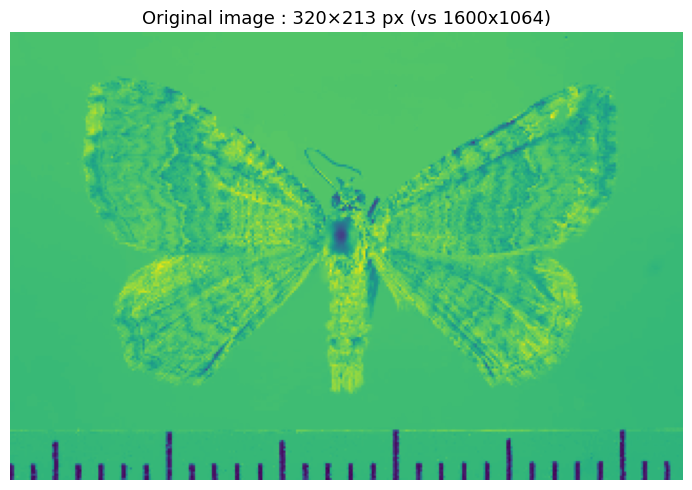

In [421]:
def load_image(path: str) -> tuple[np.ndarray, np.ndarray]:
    img = Image.open(path).convert("RGB")
    img_color = np.array(img)

    img_gray = np.dot(img_color[..., :3], [0.299, 0.587, 0.114]).astype(np.float32) / 255.0

    print(f"Image size : {img_gray.shape[1]} × {img_gray.shape[0]} px")
    return img_gray, img_color


base_img_gray, base_img_color = load_image(IMAGE_PATH)

ruler_ratio = 0

img_gray = base_img_gray[int(ruler_ratio*base_img_gray.shape[0]):, :]
img_color = base_img_color[int(ruler_ratio*base_img_color.shape[0]):, :, :]
H, W = img_gray.shape

Ho, Wo = (500, 500)

reduced_img_gray = img_gray[::RATIO, ::RATIO]
Hm, Wm = reduced_img_gray.shape

fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(reduced_img_gray)
ax.set_title(f"Original image : {Wm}×{Hm} px (vs {W}x{H})", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()


H, W = reduced_img_gray.shape

In [422]:
def fft_dominant_frequency(row: np.ndarray,
                            min_period_ratio: float,
                            max_period_ratio: float,
                            prominence: float) -> tuple[float | None, float | None]:
    """
    Applique la FFT sur une ligne de pixels et retourne
    la période dominante (en px) et sa phase.

    Paramètres
    ----------
    row           : 1D array de niveaux de gris
    min_period_px : période minimale acceptée (px)
    max_period_px : période maximale acceptée (px)
    prominence    : proéminence relative minimale du pic

    Retourne
    --------
    (période_px, phase_rad) ou (None, None) si aucun pic valide
    """
    N = len(row)

    row_centered = row - row.mean()

    window = np.hanning(N)
    row_windowed = row_centered * window

    fft_vals = np.fft.rfft(row_windowed)
    freqs    = np.fft.rfftfreq(N)   # fréquences normalisées [0, 0.5]

    magnitude = np.abs(fft_vals)

    f_min = 1.0 / (max_period_ratio * N)
    f_max = 1.0 / (min_period_ratio * N)

    mask = (freqs >= f_min) & (freqs <= f_max)
    if mask.sum() == 0:
        return None, None

    mag_masked = magnitude.copy()
    mag_masked[~mask] = 0

    peaks, props = find_peaks(mag_masked,
                              prominence=prominence * mag_masked.max())
    if len(peaks) == 0:
        return None, None

    best_peak = peaks[np.argmax(mag_masked[peaks])]

    period_px = 1.0 / freqs[best_peak]
    phase_rad = np.angle(fft_vals[best_peak])

    return period_px, phase_rad, max(mag_masked[peaks])

def cycles_observes(row, period_px, seuil_env=0.3):
    N = len(row)
    f0 = 1.0 / period_px
    row_c = row - row.mean()                 # PAS de fenêtre ici (on garde les bords)

    # bande passante autour de f0
    fft   = np.fft.rfft(row_c)
    freqs = np.fft.rfftfreq(N)
    bw    = 0.5 * f0                          # ±50 % autour de f0
    fft[(freqs < f0 - bw) | (freqs > f0 + bw)] = 0
    filtre = np.fft.irfft(fft, n=N)

    # enveloppe d'amplitude de la composante
    env = np.abs(hilbert(filtre))
    seuil = seuil_env * env.max()

    # crêtes de l'oscillation, uniquement là où elle est réellement présente
    peaks, _ = find_peaks(filtre, distance=max(1, period_px * 0.5))
    peaks = peaks[env[peaks] >= seuil]
    return len(peaks)

row_indices = np.arange(H)
if N_LINES is not None and N_LINES < H:
    row_indices = np.linspace(0, H - 1, N_LINES, dtype=int)

results = []   
n_cycles = []

for i in row_indices:
    # row = img_gray[i, :]
    row = reduced_img_gray[i, :]
    period, phase, magnitude = fft_dominant_frequency(
        row, MIN_FREQ_RATIO, MAX_FREQ_RATIO, PEAK_PROMINENCE
    )
    if period is not None:
        results.append((i, period, phase, magnitude))
        n_cycles.append(cycles_observes(row, period))

print(n_cycles)

print(f"analysed lines: {len(row_indices)}")
print(f"valid peak lines: {len(results)} ({100*len(results)/len(row_indices):.1f}%)")

[12, 12, 2, 9, 7, 10, 10, 4, 7, 7, 9, 7, 4, 5, 5, 7, 8, 8, 9, 9, 13, 5, 2, 4, 2, 5, 6, 6, 4, 4, 5, 8, 2, 5, 3, 6, 8, 8, 6, 3, 5, 5, 6, 4, 4, 5, 4, 6, 7, 4, 8, 7, 4, 6, 6, 6, 8, 4, 7, 6, 6, 5, 8, 16, 18, 9, 7, 7, 23, 8, 14, 10, 10, 15, 10, 12, 9, 6, 5, 8, 8, 9, 8, 5, 4, 3, 6, 4, 8, 2, 3, 3, 2, 3, 3, 2, 2, 2, 3, 4, 2, 3, 2, 3, 4, 3, 5, 8, 5, 11, 5, 7, 4, 4, 7, 5, 4, 7, 9, 8, 3, 8, 15, 15, 5, 3, 6, 7, 6, 4, 9, 8, 8, 15, 9, 10, 6, 15, 15, 16, 9, 9, 10, 11, 9, 7, 7, 8, 9, 12, 9, 10, 8, 3, 10, 9, 7, 7, 6, 7, 3, 3, 4, 4, 3, 2, 1, 1, 1, 1, 1, 1, 7, 9, 12, 6, 6, 6, 6, 6, 11, 12, 12, 13, 15, 15, 5, 5, 2, 4, 6, 6, 6, 6, 10, 14, 16, 16, 16, 15, 17, 16, 17, 17, 18, 30, 30, 30, 30, 30, 30, 30, 30]
analysed lines: 213
valid peak lines: 213 (100.0%)


In [423]:
# # speed test
# import time as time
# import tqdm

# ntry = H

# times = []

# for size in tqdm.tqdm(range(100, W, 200)):
#     S = 0 
#     test_row = row[:size]
#     for i in range(ntry):
#         T1 = time.time()
#         fft_dominant_frequency(test_row, MIN_FREQ_RATIO, MAX_FREQ_RATIO, PEAK_PROMINENCE)
#         T2 = time.time()
#         S += (T2 - T1)
#     times.append(S / ntry)

# print(list(range(100, W, 100)))       
# print(times)

In [424]:
# X = np.array(list(range(100, W, 200)))
# Y = np.array(times) 

# m, b = np.polyfit(X, Y, 1)
# print(m, b) # says : 1.103616662614173e-07 0.0002810560613318752
# # -> gains 10-4 seconds per 1000 px (0.5s on a 5000 px height)

# plt.scatter(X, Y)
# plt.show()

Max magnitude : 3.89
dominant period : 160.00 px -> 160.00 px / mm


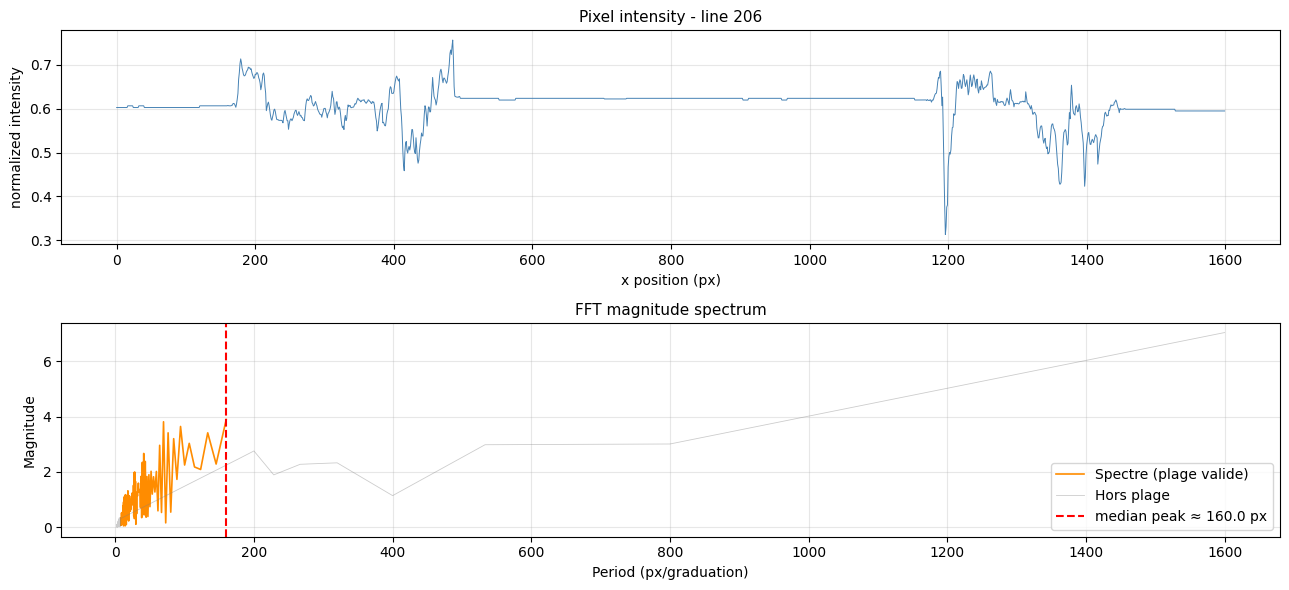

In [425]:

mag_max = 0
max_idx = 0
for i in range(len(results)):
    mid_row  = results[i][0]
    if results[i][3] > mag_max:
        mag_max = results[i][3]
        max_idx = i

mid_row = results[max_idx][0]
row_demo = img_gray[mid_row, :]
N        = len(row_demo)

row_c = row_demo - row_demo.mean()
row_w = row_c * np.hanning(N)
fft_demo  = np.fft.rfft(row_w)
freqs_demo = np.fft.rfftfreq(N)
mag_demo  = np.abs(fft_demo)

with np.errstate(divide='ignore'):
    periods_demo = np.where(freqs_demo > 0, 1.0 / freqs_demo, np.inf)

valid_mask = (periods_demo >= N * MIN_FREQ_RATIO) & (periods_demo <= N * MAX_FREQ_RATIO)

fig, axes = plt.subplots(2, 1, figsize=(13, 6))

axes[0].plot(row_demo, color='steelblue', lw=0.7)
axes[0].set_title(f"Pixel intensity - line {mid_row}", fontsize=11)
axes[0].set_xlabel("x position (px)")
axes[0].set_ylabel("normalized intensity")
axes[0].grid(True, alpha=0.3)

axes[1].plot(periods_demo[valid_mask], mag_demo[valid_mask],
             color='darkorange', lw=1.2, label='Spectre (plage valide)')
axes[1].plot(periods_demo[~valid_mask & (freqs_demo > 0)],
             mag_demo[~valid_mask & (freqs_demo > 0)],
             color='gray', lw=0.6, alpha=0.4, label='Hors plage')

if len(results) > 0:
    dominant_period = periods_demo[valid_mask][np.argmax(mag_demo[valid_mask])]
    print(f"Max magnitude : {mag_demo[valid_mask].max():.2f}")
    print(f"dominant period : {dominant_period:.2f} px -> {dominant_period:.2f} px / mm")
    axes[1].axvline(dominant_period, color='red', ls='--', lw=1.5,
                    label=f'median peak ≈ {dominant_period:.1f} px')

axes[1].set_title("FFT magnitude spectrum", fontsize=11)
axes[1].set_xlabel("Period (px/graduation)")
axes[1].set_ylabel("Magnitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Rough median period : 10.667 px
Phase slope (rad/px) : 0.005512

Estimated inclination angle : 0.536°


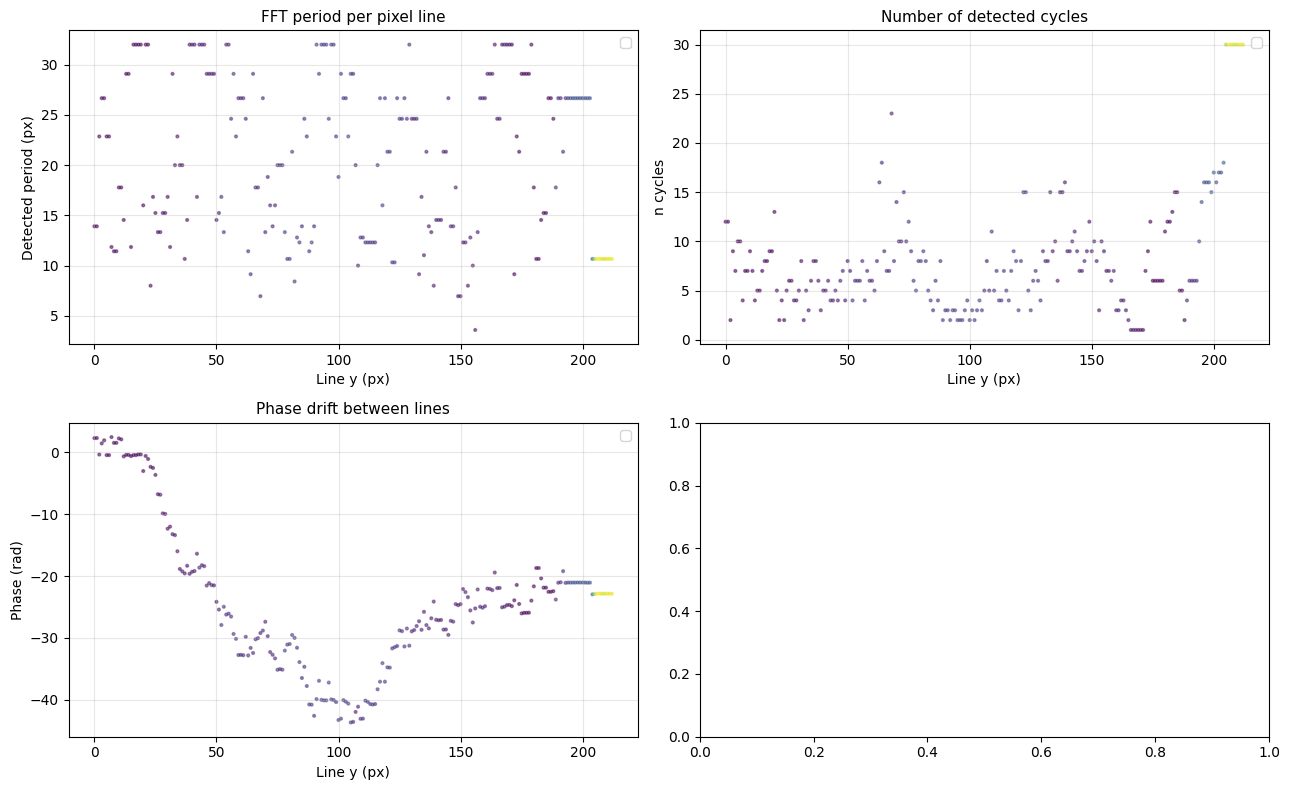

In [426]:
if len(results) < 5:
    raise RuntimeError("Error : not enough valid line")

rows_arr   = np.array([r[0] for r in results], dtype=float)
phases_arr  = np.array([r[2] for r in results], dtype=float)
mag_arr = np.array([r[3] for r in results], dtype=float)

periods_arr = np.array([r[1] for r in results], dtype=float)
max_mag = max(mag_arr)
filtered_rows = []
filtered_phases = []
filtered_periods = []
for i in range(len(results)):
    if results[i][3] == max_mag:
        filtered_rows.append(results[i][0])
        filtered_phases.append(results[i][2])
        filtered_periods.append(results[i][1])
filtered_rows_arr = np.array(filtered_rows, dtype=float)
filtered_phases_arr = np.array(filtered_phases, dtype=float)
filtered_periods_arr = np.array(filtered_periods, dtype=float)


T_median = np.median(filtered_periods_arr)
print(f"Rough median period : {T_median:.3f} px")

phases_unwrapped = np.unwrap(filtered_phases_arr)


slope_phase, intercept_phase = np.polyfit(filtered_rows_arr, phases_unwrapped, 1)

print(f"Phase slope (rad/px) : {slope_phase:.6f}")

tan_theta = slope_phase * T_median / (2 * np.pi)
theta_rad = np.arctan(tan_theta)
theta_deg = np.degrees(theta_rad)

print(f"\nEstimated inclination angle : {theta_deg:.3f}°")

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].scatter(rows_arr, periods_arr, s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis',)
axes[0, 0].set_title("FFT period per pixel line", fontsize=11)
axes[0, 0].set_xlabel("Line y (px)")
axes[0, 0].set_ylabel("Detected period (px)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[1, 0].scatter(rows_arr, np.unwrap(phases_arr), s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis')
axes[1, 0].set_title("Phase drift between lines", fontsize=11)
axes[1, 0].set_xlabel("Line y (px)")
axes[1, 0].set_ylabel("Phase (rad)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(rows_arr, n_cycles, s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis')
axes[0, 1].set_title("Number of detected cycles", fontsize=11)
axes[0, 1].set_xlabel("Line y (px)")
axes[0, 1].set_ylabel("n cycles")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Groups found : 2


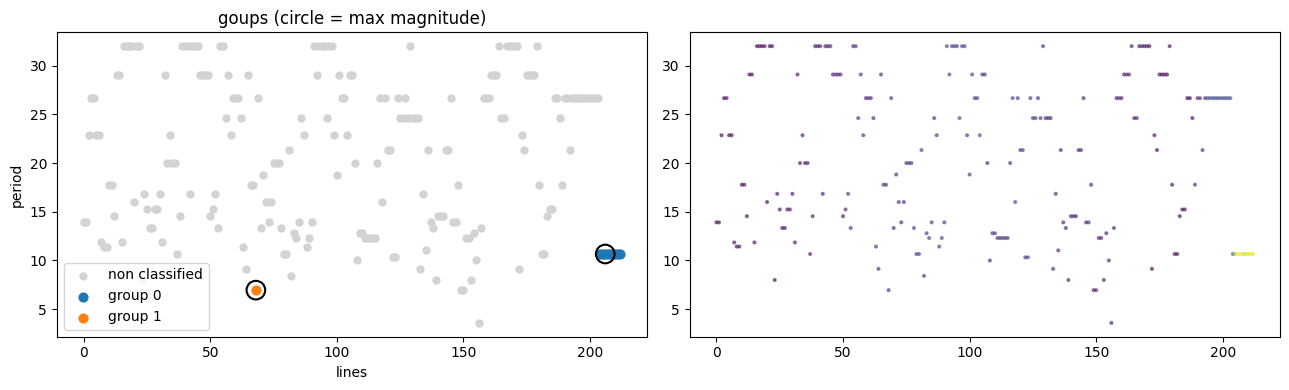

In [427]:
import numpy as np


def _pente_initiale(graine, period, lines, ordre, rang, delta, win=3):
    """Estime la pente locale period=f(lines) autour de la graine, à partir
    des points voisins (sur l'axe 'lines') restant proches en period.
    Utile quand la crête est inclinée et que la graine n'a qu'un voisin."""
    pos = rang[graine]
    fenetre = 4.0 * delta
    idx = []
    for d in range(-win, win + 1):
        p = pos + d
        if 0 <= p < len(ordre):
            c = ordre[p]
            if abs(period[c] - period[graine]) <= fenetre:
                idx.append(c)
    if len(idx) >= 2:
        a, _ = np.polyfit(lines[idx], period[idx], 1)
        return a
    return 0.0


def _croissance(graine, direction, membres, groupe_id, gid,
                period, lines, ordre, rang, delta, max_sauts, pente0):
    """Étend le groupe depuis la graine dans un sens de l'axe 'lines'."""
    pos = rang[graine]
    sauts = 0
    n = len(ordre)
    while True:
        pos += direction
        if pos < 0 or pos >= n:
            break
        cand = ordre[pos]

        # candidat déjà attribué -> on saute (trous tolérés jusqu'à max_sauts)
        if groupe_id[cand] != -1:
            sauts += 1
            if sauts > max_sauts:
                break
            continue

        # period attendu sur la droite du groupe, à cette valeur de 'lines'
        lm = lines[membres]
        pm = period[membres]
        if len(membres) >= 2:
            a, b = np.polyfit(lm, pm, 1)         # ajustement du groupe
            pred = a * lines[cand] + b
        else:
            pred = pm[0] + pente0 * (lines[cand] - lm[0])  # graine seule

        if abs(period[cand] - pred) <= delta:
            groupe_id[cand] = gid
            membres.append(cand)
            sauts = 0
        else:
            sauts += 1
            if sauts > max_sauts:
                break


def trouver_groupes(period, magnitude, lines, n_cycles, delta, max_sauts=2, n_groupes=None, min_cycles=20):
    """
    Regroupe les points (period vs lines) alignés sur une même droite.

    Paramètres
    ----------
    period, magnitude, lines : array-like (même taille)
    delta : float
        Tolérance en 'period' autour de la droite du groupe.
    max_sauts : int
        Nombre de 'lines' manquantes/rejetées tolérées avant d'arrêter
        l'extension d'un groupe (gère les trous dans une crête).

    Retour
    ------
    groupe_id : np.ndarray d'entiers (même taille)
        Identifiant de groupe (>= 0) de chaque point. La graine d'un groupe
        (son point de magnitude max) est garantie comme étant le max du groupe.
    """
    period    = np.asarray(period, dtype=float)
    magnitude = np.asarray(magnitude, dtype=float)
    lines     = np.asarray(lines, dtype=float)
    n_cycles   = np.asarray(n_cycles, dtype=float)
    n = len(period)

    groupe_id = np.full(n, -1, dtype=int)        # -1 = libre, -2 = rejeté
    ordre = np.argsort(lines)
    rang = np.empty(n, dtype=int); rang[ordre] = np.arange(n)

    gid = 0
    while np.any(groupe_id == -1):
        if n_groupes is not None and gid >= n_groupes:
            break
        libres = np.where(groupe_id == -1)[0]
        graine = libres[np.argmax(magnitude[libres])]

        membres = [graine]
        groupe_id[graine] = gid
        pente0 = _pente_initiale(graine, period, lines, ordre, rang, delta)
        _croissance(graine, +1, membres, groupe_id, gid,
                    period, lines, ordre, rang, delta, max_sauts, pente0)
        _croissance(graine, -1, membres, groupe_id, gid,
                    period, lines, ordre, rang, delta, max_sauts, pente0)

        # validation : moyenne des cycles du groupe > min_cycles
        if n_cycles[membres].mean() > min_cycles:
            gid += 1                              # groupe validé
        else:
            groupe_id[membres] = -2               # rejeté, exclu des graines

    groupe_id[groupe_id == -2] = -1               # les rejetés -> non classés
        
     # --- ré-étiquetage : groupe 0 = meilleure magnitude moyenne par point ---
    ids = [g for g in np.unique(groupe_id) if g != -1]
    moyennes = {g: magnitude[groupe_id == g].mean() for g in ids}
    ordre_groupes = sorted(ids, key=lambda g: moyennes[g], reverse=True)
    remap = {ancien: nouveau for nouveau, ancien in enumerate(ordre_groupes)}

    nouveau_id = np.full_like(groupe_id, -1)
    for ancien, nouveau in remap.items():
        nouveau_id[groupe_id == ancien] = nouveau
    groupe_id = nouveau_id

    return groupe_id


rows_arr   = np.array([r[0] for r in results], dtype=float)
phases_arr  = np.array([r[2] for r in results], dtype=float)
mag_arr = np.array([r[3] for r in results], dtype=float)

periods_arr = np.array([r[1] for r in results], dtype=float)

period, magnitude, lines = periods_arr, mag_arr, rows_arr

gid = trouver_groupes(period, magnitude, lines, n_cycles, delta=0.2, n_groupes=5)
print("Groups found :", gid.max() + 1)


fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# points non classés (groupe_id == -1)
m = gid == -1
if m.any():
    axes[0].scatter(lines[m], period[m], s=25, c="lightgray", label="non classified")

# groupes (on part de 0, en ignorant les -1)
for g in range(gid.max() + 1):
    m = gid == g
    if not m.any():
        continue
    axes[0].scatter(lines[m], period[m], s=40, label=f"group {g}")
    imax = np.argmax(np.where(m, magnitude, -np.inf))
    axes[0].scatter(lines[imax], period[imax], s=180,
                facecolors="none", edgecolors="k", linewidths=1.5)
axes[0].set_xlabel("lines"); axes[0].set_ylabel("period"); axes[0].legend()
axes[0].set_title("goups (circle = max magnitude)")


axes[1].scatter(rows_arr, periods_arr, s=4, alpha=0.5, c=[res[3] for res in results], cmap='viridis',)

plt.tight_layout()
plt.show()

In [428]:
# update of the line
indices = np.where(gid == 0)[0]
max_line_idx = int(indices.mean())
mean_period = np.asarray(periods_arr)[indices].mean()
mean_phase = np.asarray(phases_arr)[indices].mean()
print(max_line_idx, mean_period, mean_phase)

if len(np.unique(gid)) > 2:
    # other possible location
    indices_second = np.where(gid == 1)[0]
    max_line_idx_second = int(indices_second.mean())
    mean_period_second = np.asarray(periods_arr)[indices_second].mean()
    mean_phase_second = np.asarray(phases_arr)[indices_second].mean()
    print(max_line_idx_second, mean_period_second, mean_phase_second)
else:
    indices_second = indices
    max_line_idx_second = max_line_idx
    mean_period_second = mean_period
    mean_phase_second = mean_phase
    print("no other possible group")

208 10.666666666666666 2.268258418145411
68 6.956521739130434 2.2011677828983527


In [429]:
T_median = mean_period * RATIO
T_corrected = mean_period / np.cos(mean_phase) * RATIO

px_per_mm = T_corrected / GRADUATION_MM 
mm_per_px = GRADUATION_MM / T_corrected


print(f"Ruler gradation : {GRADUATION_MM:.2f} mm")
print(f"Raw period (X-axis): {T_median:.3f} px")
print(f"Inclination angle: {theta_deg:.3f} °")
print(f"Corrected period: {T_corrected:.3f} px")

print(f"px / mm: {px_per_mm:.4f} px/mm")
print(f"mm / px: {mm_per_px:.6f} mm/px")


Ruler gradation : 1.00 mm
Raw period (X-axis): 53.333 px
Inclination angle: 0.536 °
Corrected period: -83.038 px
px / mm: -83.0382 px/mm
mm / px: -0.012043 mm/px


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


(213, 320, 3)
208


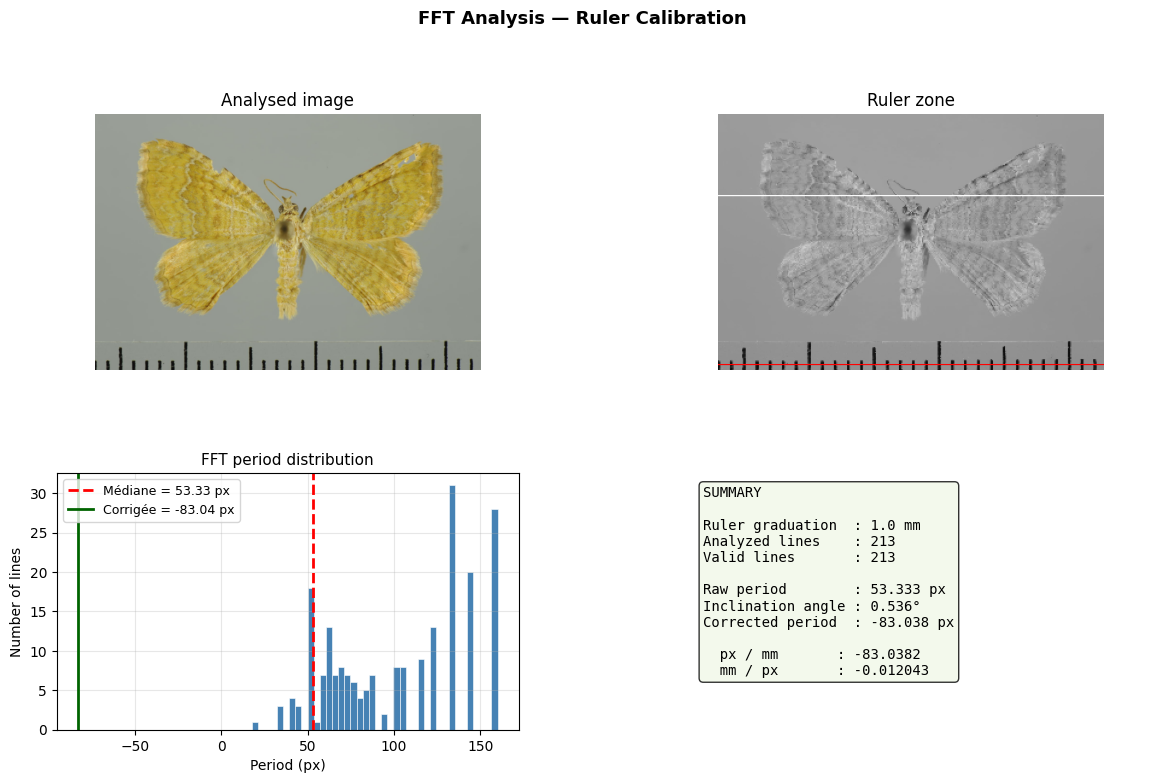

In [430]:

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(base_img_color)
ax1.set_title("Analysed image", fontsize=12)
ax1.axis('off')

info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax1.set_xlabel(info, fontsize=10, labelpad=6)
ax1.xaxis.label.set_color('darkgreen')

modif_reduced_img_gray = reduced_img_gray[..., np.newaxis]
modif_reduced_img_gray = np.concatenate([modif_reduced_img_gray, modif_reduced_img_gray, modif_reduced_img_gray], axis = 2)
print(modif_reduced_img_gray.shape)
print(max_line_idx)
modif_reduced_img_gray[max_line_idx_second, :, :] = [255, 100, 100]
modif_reduced_img_gray[max_line_idx, :, :] = [255, 0, 0]
ax4 = fig.add_subplot(gs[0, 1])
ax4.imshow(modif_reduced_img_gray)
ax4.set_title("Ruler zone", fontsize=12)
ax4.axis('off')

info = (f"  mm/px = {mm_per_px:.5f}  |  px/mm = {px_per_mm:.3f}  "
        f"|  angle = {theta_deg:.2f}°  ")
ax4.set_xlabel(info, fontsize=10, labelpad=6)
ax4.xaxis.label.set_color('darkgreen')

ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(periods_arr * RATIO, bins=40, color='steelblue', edgecolor='white', lw=0.4)
ax2.axvline(T_median, color='red', ls='--', lw=2,
            label=f'Médiane = {T_median:.2f} px')
ax2.axvline(T_corrected, color='darkgreen', ls='-', lw=2,
            label=f'Corrigée = {T_corrected:.2f} px')
ax2.set_title("FFT period distribution", fontsize=11)
ax2.set_xlabel("Period (px)")
ax2.set_ylabel("Number of lines")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
summary_lines = [
    "SUMMARY",
    "",
    f"Ruler graduation  : {GRADUATION_MM} mm",
    f"Analyzed lines    : {len(row_indices)}",
    f"Valid lines       : {len(results)}",
    "",
    f"Raw period        : {T_median:.3f} px",
    f"Inclination angle : {theta_deg:.3f}°",
    f"Corrected period  : {T_corrected:.3f} px",
    "",
    f"  px / mm       : {px_per_mm:.4f}",
    f"  mm / px       : {mm_per_px:.6f}",
]
summary_text = "\n".join(summary_lines)
ax3.text(0.05, 0.95, summary_text,
         transform=ax3.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f8e8', alpha=0.8))

plt.suptitle("FFT Analysis — Ruler Calibration",
             fontsize=13, fontweight='bold', y=1.01)
plt.show()
